# Credit card fraud detection

# LightGBM | XGBoost Pipeline only!

## Introduction

The machine learning project aims to detect fraudulent credit card transaction, which is a growing problem for the banking industry and also for consumers. Due to growing scam and social engineering activities more people are victims. Therefore there are multiple stakeholders (regulatory authorities EBA & ECB, banks, consumers) interested in a sufficient fraud prevention and detection. 



The project is a classification problem, with highly unbalanced proportions of our to explainable variable y (is_fraud). Classifing the transaction into fraudulent transaction, while actually being fraudulent transaction is crucial for the credit card originating bank. Not detecting fraudulent transaction leads to financial liability damages, binding workers recourses and also damaging the reputation of the bank as safe financial service provider. Marked false positive transactions are also a problem for the bank business. Getting warning messages to the client or even blocking the credit card results into less card activity and therefore less revenue and profit for the bank. In the worst case clients will even terminate their credit card contract, because the credit card is not reliable when it should be. The declined using of a (business) credit card, for a late hotel check in, is horrible and for sure not a nice experience in a tight working schedule.    


This project considers the current developments in academic discussion and uses their approaches, mainly the recent published paper by "Shi et al (2025): An attention-based balanced variational autoencoder method for credit card fraud detection", on a different dataset which is publicly available on Hugging Face by the following link:

https://huggingface.co/datasets/pointe77/credit-card-transaction

The credit card data (most likely synthetic data) is downloaded from Hugging face, without providing any descriptions.Nevertheless the used variables are quit obvious, by their structure and their content. So the qualitative data description will be conducted on industrial experience and best guesses.


The Script CC_Fraud_DATA_Prep.ipynb already creates via feature engineering variables from the initial dataset which is based on the initial Hugging Face dataset and the FBI Crime Data. To make this script cleaner this script starts, with the used dataset description and then provides the model usage.  

## PROBLEM The engineered feature: dist_client_merchant was used to generate the variable is Fraud!

## General steps in this Project
As first step the dataset is changed and enriched with constructed variables (feature engineering) to get a better explanibility for classification fraud. Those steps are seperated in the script (CC_Fraud_Data_Prep.ipynb). A descriptive analysis of the constructed and original dataset is conducted, by using descriptive statistics and some visualisations. Since the dataset is not just a simple cross sectional dataset, not considering any time dependet relations could be fatally missing any crucial trends. A short time series analysis of our dataset is therefore included.

The feature enigineering of variables leads in multiple variables which are highly correlated to each other (by being based on the same features). Therefore the project contains LightGBM / Lasso Regression just for the purpose of deciding and selecting variables, which variables more efficiently leads to a better explanibilty. 
Both procedures are included, to get a more decisive analysis of the variable, whereas the lasso regression investigates linear relationship it provides negative or positive links to our fraud marker (y), which is a valuable information for the bank and future steps in avoiding fraud.  


In [4]:
# Importing standard packages
import polars as pl # Faster then pandas, 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # visualization
#import sklearn as 

from geopy.distance import distance #, geodesic, great_circle # Feature Engineering module for Geodata

In [5]:
# reading in the datasets

cc_train =  pl.read_parquet("credit_card_trans_train.parquet")
cc_test  = pl.read_parquet("credit_card_trans_test.parquet")
# cc_comb = pl.concat([cc_train, cc_test])
# del(cc_train, cc_test)


In [6]:
cc = cc_train
# Trans_num as ID and seperate Information DataFrame 
# To make the Data_Frame nicer to handle all Identifier variables and some string variables are seperated from the dataset:
#  
"""
cc_ID = 
print(f"Columns: {cc.columns.drop('')}")
"""
cc.head(5)


Owner_ID,cc_num,trans_num,trans_date_trans_time,merchant,category,amt,gender,city_pop,job,merch_long,is_fraud,State_Risk_Rating,dist_client_merchant,trans_date,trans_week,trans_time_diff,travel_time_km,daily_transactions,weekly_transactions,net_binary,Population_Density,birth_year,generation,amt_iqr_ratio,Amount_Outlier_bin,net_binary_comb_travel_time,net_binary_comb_trans_time,Amount_Outlier_bin_comb_amt
u64,i64,str,datetime[μs],str,str,f64,str,i64,str,f64,i64,i64,f64,date,i8,f64,f64,u32,u32,i32,str,i32,str,f64,i32,f64,f64,f64
385639284318030378,60416207185,"""98e3dcf98101146a577f85a34e58fe…",2019-01-01 12:47:15,"""fraud_Jones, Sawayn and Romagu…","""misc_net""",7.27,"""F""",1645,"""Information systems manager""",-109.741904,0,2353556,127.629296,2019-01-01,1,0.0,0.0,1,28,0,"""Village""",1986,"""Millennials""",0.113187,0,0.0,0.0,0.0
385639284318030378,60416207185,"""498120fc45d277f7c88e3dba79c338…",2019-01-02 08:44:57,"""fraud_Berge LLC""","""gas_transport""",52.94,"""F""",1645,"""Information systems manager""",-109.044172,0,2353556,110.202992,2019-01-02,1,71862.0,0.003126,4,28,1,"""Village""",1986,"""Millennials""",0.824225,0,0.003126,71862.0,0.0
385639284318030378,60416207185,"""95f514bb993151347c7acdf8505c3d…",2019-01-02 08:47:36,"""fraud_Luettgen PLC""","""gas_transport""",82.08,"""F""",1645,"""Information systems manager""",-109.157564,0,2353556,21.841827,2019-01-02,1,159.0,0.661115,4,28,1,"""Village""",1986,"""Millennials""",1.277908,0,0.661115,159.0,0.0
385639284318030378,60416207185,"""4f0c1a14e0aa7eb56a490780ef9268…",2019-01-02 12:38:14,"""fraud_Daugherty LLC""","""kids_pets""",34.79,"""F""",1645,"""Information systems manager""",-108.747683,0,2353556,87.12442,2019-01-02,1,13838.0,0.006367,4,28,1,"""Village""",1986,"""Millennials""",0.541647,0,0.006367,13838.0,0.0
385639284318030378,60416207185,"""3b2ebd3af508afba959640893e1e82…",2019-01-02 13:10:46,"""fraud_Beier and Sons""","""home""",27.18,"""F""",1645,"""Information systems manager""",-108.091143,0,2353556,74.352876,2019-01-02,1,1952.0,0.068047,4,28,1,"""Village""",1986,"""Millennials""",0.423167,0,0.068047,1952.0,0.0


### A Short general description of the dataset and the difference to the original dataset.

The first variables contain Keyident data on different levels. We originated an unique OwnerID instead of the name, a CC_num (Credit Card Number) and trans_num (Transaction number) already existed, to identify fraudulent transaction and the related owner and card. 
The original dataset contains location data which is partly written as string dtype and also in latitude and longitude of customer and also merchant data. Since we derived in the feature engineering script the following variables: #LIST# -> The Variables: street	city	state	zip	lat	long merch_lat	merch_long merch_zipcode are deleted. 
The transaction date information is used to derive daily and weekly timestamps and based on these timestamps and location data the following features are derived: #LIST#.



Threshold in noon (2020, 6, 21)

## First Overview of the Data

### Qualitative Description of the DATA, What the Variables mean.



In [7]:
# Since we got labeled data we can check the Time Series of fraud activity (at least for this data, the reality might be different with unlabeled data):
cc = cc_train
min_date = cc['trans_date'].min()

# weeks since start
cc = cc.with_columns(
    ((pl.col('trans_date') - min_date).dt.total_days() / 7).floor().cast(pl.Int32).alias('week_index')
)

# Aggregation weekly data
weekly_stats = cc.group_by(['week_index']).agg([
    pl.len().alias('total_transactions'),
    pl.col('is_fraud').sum().alias('fraud_count'),
    (pl.col('is_fraud').sum() / pl.len() * 100).alias('fraud_percentage')
]).sort(['week_index'])


Owner_ID,cc_num,trans_num,trans_date_trans_time,merchant,category,amt,gender,city_pop,job,merch_long,is_fraud,State_Risk_Rating,dist_client_merchant,trans_week,trans_time_diff,travel_time_km,daily_transactions,weekly_transactions,net_binary,Population_Density,birth_year,generation,amt_iqr_ratio,Amount_Outlier_bin,net_binary_comb_travel_time,net_binary_comb_trans_time,Amount_Outlier_bin_comb_amt
u64,i64,str,datetime[μs],str,str,f64,str,i64,str,f64,i64,i64,f64,i8,f64,f64,u32,u32,i32,str,i32,str,f64,i32,f64,f64,f64
385639284318030378,60416207185,"""98e3dcf98101146a577f85a34e58fe…",2019-01-01 12:47:15,"""fraud_Jones, Sawayn and Romagu…","""misc_net""",7.27,"""F""",1645,"""Information systems manager""",-109.741904,0,2353556,127.629296,1,0.0,0.0,1,28,0,"""Village""",1986,"""Millennials""",0.113187,0,0.0,0.0,0.0
385639284318030378,60416207185,"""498120fc45d277f7c88e3dba79c338…",2019-01-02 08:44:57,"""fraud_Berge LLC""","""gas_transport""",52.94,"""F""",1645,"""Information systems manager""",-109.044172,0,2353556,110.202992,1,71862.0,0.003126,4,28,1,"""Village""",1986,"""Millennials""",0.824225,0,0.003126,71862.0,0.0
385639284318030378,60416207185,"""95f514bb993151347c7acdf8505c3d…",2019-01-02 08:47:36,"""fraud_Luettgen PLC""","""gas_transport""",82.08,"""F""",1645,"""Information systems manager""",-109.157564,0,2353556,21.841827,1,159.0,0.661115,4,28,1,"""Village""",1986,"""Millennials""",1.277908,0,0.661115,159.0,0.0
385639284318030378,60416207185,"""4f0c1a14e0aa7eb56a490780ef9268…",2019-01-02 12:38:14,"""fraud_Daugherty LLC""","""kids_pets""",34.79,"""F""",1645,"""Information systems manager""",-108.747683,0,2353556,87.12442,1,13838.0,0.006367,4,28,1,"""Village""",1986,"""Millennials""",0.541647,0,0.006367,13838.0,0.0
385639284318030378,60416207185,"""3b2ebd3af508afba959640893e1e82…",2019-01-02 13:10:46,"""fraud_Beier and Sons""","""home""",27.18,"""F""",1645,"""Information systems manager""",-108.091143,0,2353556,74.352876,1,1952.0,0.068047,4,28,1,"""Village""",1986,"""Millennials""",0.423167,0,0.068047,1952.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
15068557676874330645,4992346398065154184,"""ad7dfdf0aaa36cd7985dd1f35ca0e2…",2020-06-20 21:04:59,"""fraud_Berge, Kautzer and Harri…","""personal_care""",60.47,"""M""",532,"""Audiological scientist""",-89.076105,0,2675478,78.397703,25,30740.0,0.002344,4,62,1,"""Village""",1956,"""Boomer""",0.825754,0,0.002344,30740.0,0.0
15068557676874330645,4992346398065154184,"""6d427d735c9f9b2fd480f2c24b6525…",2020-06-21 00:41:01,"""fraud_Bernhard Inc""","""gas_transport""",74.29,"""M""",532,"""Audiological scientist""",-89.553379,0,2675478,55.384911,25,12962.0,0.003872,4,62,1,"""Village""",1956,"""Boomer""",1.014475,0,0.003872,12962.0,0.0
15068557676874330645,4992346398065154184,"""9814049bcc69fb31d81f4a907f2fe2…",2020-06-21 02:47:59,"""fraud_Reichert, Rowe and Mraz""","""shopping_net""",246.56,"""M""",532,"""Audiological scientist""",-88.682562,0,2675478,115.590006,25,7618.0,0.012379,4,62,0,"""Village""",1956,"""Boomer""",3.366926,0,0.0,0.0,0.0


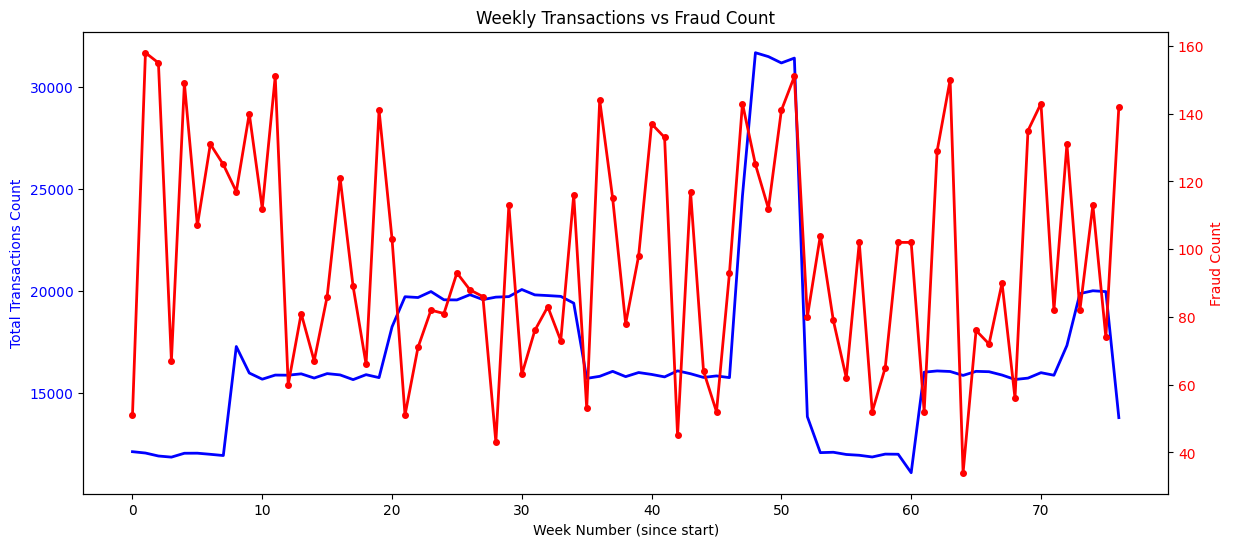

In [8]:
# Plot using week_index
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(weekly_stats['week_index'], weekly_stats['total_transactions'], 
         label='Total Transactions', color='blue', linewidth=2)
ax1.set_xlabel('Week Number (since start)')
ax1.set_ylabel('Total Transactions Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(weekly_stats['week_index'], weekly_stats['fraud_count'], 
         label='Fraud Count', color='red', linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Fraud Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Weekly Transactions vs Fraud Count')

cc.drop(['trans_date','week_index'])

Checking the Time Series visualy, the following seems to apply:
The fraud count seems to be stationary. Dickey Fuller Test can be conducted as addition.
The CC usage seems to get some seasonality, unfortunately the data does not cover multiple years (annualy seasonality seems to be dominating) and therefore it might be unsufficient to feature engineer. 
The rise of CC usage for christmas and then the low account balance afterwards is clearly visable. 

No strong trend (fraud isn't systematically increasing or decreasing)
No seasonality (no weekly, monthly, or quarterly patterns)
No memory effect (past fraud doesn't predict future fraud)

## ENCODING

II.1) Feature Representation
TODO: Adapt text to newer version
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

In comparison to the algorithm of the Machine Learning course provided by UWM, in this tree based pipeline a more simplified preprocessing is conducted. First of all, since there are no missings in the dataset (Which is not totally unrealistic for those personal data and transaction data, considering the high regulation of data lineage and data quality in banks, their credit card transaction data is originated in their banking systems. It is more likelly that the personal data is not actual, which happens often, but is not easy to measure or consider.) the imputation step is skipped.
The scaling of numeric variables is for tree based alorithms skipped as well, since the splits are based on value comparisons.


In [9]:
# cleaning up preprocessing and the pipeline:
"""
Dr. Example:

num_values_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),      # Imputing is not necessary in this dataset
    MinMaxScaler(),                      # Numeric variables does not need a scaling for TreeBased Algos
)
cat_values_pipeline = make_pipeline(
    OrdinalEncoder(handle_unknown='error'), # Encoding more to differiante
)

preprocessing_pipeline = ColumnTransformer([
    ('num_attributes_steps', num_values_pipeline, data.select_dtypes('number').columns),
    ('cat_attributes_steps', cat_values_pipeline, ('protocol_type', 'service', 'flag', 'labels')),
])

THEN AFTER preprocessing_pipeline:

data_preprocessed = pd.DataFrame(
    preprocessing_pipeline.fit_transform(data), 
    columns=preprocessing_pipeline.get_feature_names_out(),
    index=data.index,
)

"""


"\nDr. Example:\n\nnum_values_pipeline = make_pipeline(\n    SimpleImputer(strategy='mean'),      # Imputing is not necessary in this dataset\n    MinMaxScaler(),                      # Numeric variables does not need a scaling for TreeBased Algos\n)\ncat_values_pipeline = make_pipeline(\n    OrdinalEncoder(handle_unknown='error'), # Encoding more to differiante\n)\n\npreprocessing_pipeline = ColumnTransformer([\n    ('num_attributes_steps', num_values_pipeline, data.select_dtypes('number').columns),\n    ('cat_attributes_steps', cat_values_pipeline, ('protocol_type', 'service', 'flag', 'labels')),\n])\n\nTHEN AFTER preprocessing_pipeline:\n\ndata_preprocessed = pd.DataFrame(\n    preprocessing_pipeline.fit_transform(data), \n    columns=preprocessing_pipeline.get_feature_names_out(),\n    index=data.index,\n)\n\n"

In [10]:
' Checking Values Descriptive Stats'

' Checking Values Descriptive Stats'

(Dornadula & Geetha, 2019): "Firstly, we use clustering method to divide the cardholders into different clusters/groups based on their transaction amount, i.e., high, medium and low using range partitioning.  Using Sliding-Window method, we aggregate the transactions into respective groups, i.e., extract some features from window to find cardholder's behavioural patterns. Features like maximum amount, minimum amount of transaction, followed by the average amount in the window and even the time elapsed."
/* features extraction related to amount */  ai1=MAX_AMT(Ti);  ai2=MIN_AMT(Ti);  ai3=AVG_AMT(Ti);  ai4=AMT(Ti);  For j in range i+w-1:  /* Time elapse */  xi= Time(tj)-Time(tj-1)  End  Xi= (ai1, ai2,ai3,ai4,ai5,);

In [ ]:
def stat_values(df: pl.DataFrame, numeric_vars: list) -> pl.DataFrame:
    
    stats_list = []
    for col in numeric_vars: 
        stats = {
            "variable": col,
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std(),
            "variance": df[col].var(),
            "min": df[col].min(),
            "q1": df[col].quantile(0.25),
            "q3": df[col].quantile(0.75),
            "max": df[col].max(),
            "range": df[col].max() - df[col].min(),
            "iqr": df[col].quantile(0.75) - df[col].quantile(0.25),
            "skewness": df[col].skew(),
            "kurtosis": df[col].kurtosis(),
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

# Usage
stats_df = stat_values(cc, ['amt','trans_time_diff','travel_time_km','daily_trans_lagged'])
stats_df

variable,mean,median,std,variance,min,q1,q3,max,range,iqr,skewness,kurtosis
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""amt""",70.351035,47.52,160.316039,25701.232223,1.0,9.65,83.14,28948.9,28947.9,73.49,42.277825,4545.627447
"""amt_iqr_ratio""",1.089604,0.683161,2.473006,6.115757,0.008158,0.14334,1.352624,438.238732,438.230574,1.209285,39.007361,4103.584458
"""trans_time_diff""",32460.388633,16536.0,47391.441671,2.2459e9,0.0,5996.0,40195.0,1.341471e6,1.341471e6,34199.0,4.278666,31.993842
"""travel_time_km""",0.052506,0.005553,1.054583,1.112146,0.0,0.002106,0.016307,216.754079,216.754079,0.014201,95.150222,12235.421253
"""daily_transactions""",4.998114,4.0,3.195478,10.211083,1.0,3.0,7.0,34.0,33.0,4.0,1.430054,3.327009
"""weekly_transactions""",39.067092,36.0,20.116603,404.677724,1.0,24.0,52.0,121.0,120.0,28.0,0.641473,0.006431


In [12]:

# extreme outliers: log transform; net_binary_comb_travel_time, net_binary_comb_trans_time


Amounts got extreme Outliers. In Basic Data.
Transformation (No 0 or negative Values makes it easier) -> log transformation.


In [13]:
def categorical_stats(df: pl.DataFrame, categorical_vars: list) -> pl.DataFrame:
    stats_list = []
    for col in categorical_vars:
        
        value_counts = df[col].value_counts()
                
        most_frequent = value_counts[0, col]
        most_freq_count = value_counts[0, "count"] 
        
        stats = {
            "variable": col,
            "n_unique": df[col].n_unique(),
            "most_frequent": most_frequent,
            "most_freq_pct": (most_freq_count / df.height) * 100,
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

cat_stats = categorical_stats(cc, ['category','merchant','State_Risk_Rating','Population_Density'])#,'generation'])

# None used variables Job

In [14]:
cat_stats

variable,n_unique,most_frequent,most_freq_pct
str,i64,str,f64
"""category""",14,"""shopping_net""",7.522548
"""merchant""",693,"""fraud_Hamill-D'Amore""",0.133187
"""State_Risk_Rating""",51,"""2051237""",1.863844
"""Population_Density""",5,"""Village""",60.864827


II.1) Feature Representation
TODO:
By using a ordinal range/categories for the variables,  it results in some better model performances. 
(Linear SVM, Logistic Regression) -Linear SVM for this data not used.
Whereas we will use the scaled integer values, for our tree based models. (XGBoost, LightGBM)  

The following Variables are therefore transformed:

- City Population
- State Risk Rating

Ordinal text variables:
Following the Lab4 - OrdinalEncoder will be used from the preprocessing module in Scikit-learn. 

## Preprocessing and Scaling different for the steps: LASSO - LSVM | LightGBM - XGBoost

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Preprocessing with encoding 

preprocessor = ColumnTransformer([
    ('state_risk', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['State_Risk_Rating']),
    ('population', OrdinalEncoder(categories=[['Village', 'Small_Town', 'Town', 'City', 'Metropolitan_Area']], handle_unknown='use_encoded_value', unknown_value=-1), ['Population_Density']),
    #('generation', OrdinalEncoder(categories=[['War_generation', 'Boomer', 'Gen X', 'Millennials', 'Gen Z']], handle_unknown='use_encoded_value', unknown_value=-1), ['generation']),
    ('pass', 'passthrough', [
        'amt', 'trans_time_diff', 
        'travel_time_km', 'daily_trans_lagged', 
        'net_binary', 'Amount_Outlier_bin', 'birth_year',
        'net_binary_comb_trans_time','net_binary_comb_travel_time'
    ]),  # unchanged variables
]) 

Maybe Winsorization for some variables (extreme outliers....), therefore cutting them...

## Light GBM as feature selection

To filtering useless features and also checking the hirarchy of our highly multicollinearated features, to make our final decision about the model input features, LightGBM is used. 
This approach follows the publication by S. Shi et al. (2025, p. 3): "We apply LightGBM as the tool to conduct an #automatic feature selection process.LightGBM, developed by Microsoft in 2017, is a tree-based gradient-boosting framework. Its most extraordinary advantages are efficiency and distributed computing. There are built-in functions that can calculate feature importance scores automatically and visualize the sortation of importance."

In [16]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
# pipeline with LightGBM (Non Linear relationships)
pipeline_LGB = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        class_weight='balanced'
    ))
])

In [ ]:
X = cc['amt',
 #,
 'trans_time_diff',
 'travel_time_km',
 'daily_trans_lagged',
 'net_binary_comb_travel_time',
 'net_binary_comb_trans_time',
 'birth_year',
 #'weekly_transactions',
 'net_binary',
 'Amount_Outlier_bin',
 'State_Risk_Rating',
 'Population_Density'].to_pandas()

y = cc['is_fraud'].to_numpy()

In [18]:
pipeline_LGB.fit(X, y)

feature_importance = pipeline_LGB.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': pipeline_LGB.named_steps['preprocessor'].get_feature_names_out(),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2073
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Tree based Multicollinearity is not an issue!

The result of LGBM leads to the following list of features: 
All amount variables are relevant, which is to PAPER CITATION!.
Daily_transactions was excluded as weekly_transactions provides a more stable and comprehensive measure of transaction frequency while capturing the same underlying pattern. Net_binary was retained over net_binary_comb_trans_time due to its stronger predictive signal. Birth_year was kept instead of the generation classification variable, because it showed higher importance.

In [ ]:
import pandas as pd
correlation_matrix = pd.DataFrame({
    'amt': X['amt'],
    #: X[], not allowed because global variable!
    #'Amount_Outlier_bin_comb_amt': X['Amount_Outlier_bin_comb_amt'], same problem
    'travel_time_km': X['travel_time_km'], # Out
    'net_binary_comb_travel_time': X['net_binary_comb_travel_time'], 
    'net_binary_comb_trans_time': X['net_binary_comb_trans_time'],
    'trans_time_diff': X['trans_time_diff'] # Out
}).corr()
correlation_matrix

,amt,amt_iqr_ratio,Amount_Outlier_bin_comb_amt,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,trans_time_diff
amt,1.000000,0.960308,0.942174,0.001134,-0.000951,-0.006155,-0.003419
amt_iqr_ratio,0.960308,1.000000,0.921295,0.000969,-0.001120,-0.000930,0.000808
Amount_Outlier_bin_comb_amt,0.942174,0.921295,1.000000,0.002366,-0.000490,-0.018123,-0.005867
travel_time_km,0.001134,0.000969,0.002366,1.000000,0.914238,-0.028308,-0.032031
net_binary_comb_travel_time,-0.000951,-0.001120,-0.000490,0.914238,1.000000,-0.025573,-0.029294
net_binary_comb_trans_time,-0.006155,-0.000930,-0.018123,-0.028308,-0.025573,1.000000,0.892473
trans_time_diff,-0.003419,0.000808,-0.005867,-0.032031,-0.029294,0.892473,1.000000


## Selection of Features

In [ ]:
# Feature Update.
relevant_Feat=['amt',
 ,
 #'dist_client_merchant', # ERROR perfect predictability
 #'trans_time_diff', OUT!
 'travel_time_km',
 #'daily_trans_lagged', OUT!
 'net_binary_comb_travel_time',
 'net_binary_comb_trans_time',
 #'Amount_Outlier_bin_comb_amt',
 'birth_year',
 'weekly_transactions',
 #'net_binary', OUT!
 #'Amount_Outlier_bin', OUT!
 'State_Risk_Rating',
 #'generation', OUT!
 'Population_Density']

Mentioned models for CC Fraud Detection in 

Dornadula, V. N., & Geetha, S. (2019). Credit Card Fraud Detection using Machine Learning Algorithms. Procedia Computer Science, 165, 631–641. https://doi.org/10.1016/j.procs.2020.01.057

XGBoost, KNN, SVM.

Decision to use XGBoost & LinearSVM (instead of KNN), because of more dimensionalities and also faster calculation.

Also in:
(Tiwari et al., 2021, p. 4):"Support Vector Machines  Support vector machines or SVMs are linear classifiers as stated in [5] that work in high dimensionality because in high-dimensions, a non-linear task in input becomes linear and hence this makes SVMs highly useful for detecting frauds. Due to its two most important features that is a kernel function to represent classification function in the dot product of input data point projection, and the fact that it tries finding a hyperplane to maximize separation between classes while minimizing overfitting of training data, it provides a very high generalization capability."

In [21]:
print("Columns in X:", X.columns.tolist())
print("\nIs 'is_fraud' in X?", 'is_fraud' in X.columns)

Columns in X: ['amt', 'amt_iqr_ratio', 'trans_time_diff', 'travel_time_km', 'daily_transactions', 'net_binary_comb_travel_time', 'net_binary_comb_trans_time', 'Amount_Outlier_bin_comb_amt', 'birth_year', 'weekly_transactions', 'net_binary', 'Amount_Outlier_bin', 'State_Risk_Rating', 'Population_Density']

Is 'is_fraud' in X? False


In [22]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform

In [23]:
# Update in the preprocessor:
relevant_feat_pass = relevant_Feat.copy()
relevant_feat_pass.remove('State_Risk_Rating')
relevant_feat_pass.remove('Population_Density')

preprocessor = ColumnTransformer([
    ('state_risk', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['State_Risk_Rating']),
    ('population', OrdinalEncoder(categories=[['Village', 'Small_Town', 'Town', 'City', 'Metropolitan_Area']], handle_unknown='use_encoded_value', unknown_value=-1), ['Population_Density']),
    #('generation', OrdinalEncoder(categories=[['War_generation', 'Boomer', 'Gen X', 'Millennials', 'Gen Z']], handle_unknown='use_encoded_value', unknown_value=-1), ['generation']),
    ('pass', 'passthrough',relevant_feat_pass),  # unchanged variables
]) 

In [24]:
## XGBoost as Model
#preprocessor = preprocessor.transformers.pop(2) #dropping generation encoding

pipeline_xgboost = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

In [25]:
pipeline_xgboost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state_risk', ...), ('population', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [26]:
hiperparam_distributions = {
    'classifier__n_estimators': randint(50, 100),           # Number of trees
    'classifier__max_depth': randint(3, 10),                # Tree depth - pretty high with 8
    'classifier__learning_rate': uniform(0.01, 0.3),        # Step size shrinkage - learning rate seems about 5% reasonable
    'classifier__subsample': uniform(0.6, 0.4),             # Row sampling
    'classifier__colsample_bytree': uniform(0.6, 0.4),      # Column sampling
    'classifier__min_child_weight': randint(1, 10),         # Min instances in leaf
    'classifier__gamma': uniform(0, 0.5),                   # Min loss reduction
    'classifier__reg_alpha': uniform(0, 1),                 # L1 regularization
    'classifier__reg_lambda': uniform(0.5, 1.5)             # L2 regularization
}

In [27]:
randomized_search_xgb = RandomizedSearchCV(
    pipeline_xgboost,
    hiperparam_distributions,
    n_iter=10,
    cv=5,
    scoring={'roc_auc': 'roc_auc',
        'accuracy': 'accuracy'},
    refit='roc_auc',                 
    random_state=42,
    n_jobs=-1,                         
    verbose=1 
)


In [28]:
x = X[relevant_Feat]
x.head(5)

,amt,amt_iqr_ratio,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year,weekly_transactions,State_Risk_Rating,Population_Density
0,7.27,0.113187,0.000000,0.000000,0.0,1986,28,2353556,Village
1,52.94,0.824225,0.003126,0.003126,71862.0,1986,28,2353556,Village
2,82.08,1.277908,0.661115,0.661115,159.0,1986,28,2353556,Village
3,34.79,0.541647,0.006367,0.006367,13838.0,1986,28,2353556,Village
4,27.18,0.423167,0.068047,0.068047,1952.0,1986,28,2353556,Village


In [29]:
randomized_search_xgb.fit(x, y)
print("Best params:", randomized_search_xgb.best_params_)
print("Best score:", randomized_search_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'classifier__colsample_bytree': np.float64(0.9895022075365837), 'classifier__gamma': np.float64(0.11638567021515211), 'classifier__learning_rate': np.float64(0.03718193035984624), 'classifier__max_depth': 8, 'classifier__min_child_weight': 3, 'classifier__n_estimators': 93, 'classifier__reg_alpha': np.float64(0.5142344384136116), 'classifier__reg_lambda': np.float64(1.3886218532930636), 'classifier__subsample': np.float64(0.6185801650879991)}
Best score: 0.9774446306389961


In [40]:
for col in X_test.columns:
    if col not in perfect_predictors:
        # Calculate how well this feature separates classes
        fraud_mean = X_test[col][y_test == 1].mean()
        nonfraud_mean = X_test[col][y_test == 0].mean()
        fraud_std = X_test[col][y_test == 1].std()
        nonfraud_std = X_test[col][y_test == 0].std()
        
        # T-test or simple separation score
        separation = abs(fraud_mean - nonfraud_mean) / (fraud_std + nonfraud_std + 0.001)
        
        if separation > 3:  # More than 3 standard deviations apart
            print(f"⚠️ NEAR-PERFECT: {col}")
            print(f"   Fraud mean: {fraud_mean:.4f} ± {fraud_std:.4f}")
            print(f"   Non-fraud mean: {nonfraud_mean:.4f} ± {nonfraud_std:.4f}")
            print(f"   Separation score: {separation:.2f}")

TypeError: Cannot perform reduction 'mean' with string dtype

In [30]:
from xgboost import XGBClassifier
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('classifier', XGBClassifier(
        n_estimators = randomized_search_xgb.best_params_['classifier__n_estimators'],
        max_depth = randomized_search_xgb.best_params_['classifier__max_depth'],
        learning_rate = randomized_search_xgb.best_params_['classifier__learning_rate'],
        subsample = randomized_search_xgb.best_params_['classifier__subsample'],
        colsample_bytree = randomized_search_xgb.best_params_['classifier__colsample_bytree'],
        min_child_weight = randomized_search_xgb.best_params_['classifier__min_child_weight'],
        gamma = randomized_search_xgb.best_params_['classifier__gamma'],
        reg_alpha  = randomized_search_xgb.best_params_['classifier__reg_alpha'],
        reg_lambda = randomized_search_xgb.best_params_['classifier__reg_lambda'],
        random_state=42,  
        eval_metric='logloss'  
    ))
])

In [31]:
X_test = cc_test[relevant_Feat].to_pandas()  
y_test = cc_test['is_fraud'].to_pandas()
X_test

,amt,amt_iqr_ratio,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year,weekly_transactions,State_Risk_Rating,Population_Density
0,124.66,1.862265,0.000000,0.000000,0.0,1986,2,2353556,Village
1,78.52,1.172991,0.007045,0.007045,11994.0,1986,2,2353556,Village
2,65.25,0.974754,0.003757,0.003757,55977.0,1986,20,2353556,Village
3,87.74,1.310726,0.002136,0.002136,27238.0,1986,20,2353556,Village
4,148.02,2.211234,0.000995,0.000995,75383.0,1986,20,2353556,Village
...,...,...,...,...,...,...,...,...,...
555714,66.11,0.882526,0.013673,0.013673,8077.0,1956,34,2675478,Village
555715,4.58,0.061140,0.008705,0.000000,0.0,1956,34,2675478,Village
555716,95.96,1.281004,0.003377,0.003377,21729.0,1956,34,2675478,Village
555717,149.48,1.995461,1.083131,1.083131,101.0,1956,34,2675478,Village


In [32]:
# Predict on test set
best_pipeline.fit(x, y) 
y_pred_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_class = best_pipeline.predict(X_test)

# Calculate performance
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

auc_test = roc_auc_score(y_test, y_pred_test)
accuracy_test = accuracy_score(y_test, y_pred_class)

In [33]:
for col in X_test.columns:
    if col != 'dist_client_merchant':  # Already found
        fraud_vals = set(X_test[col][y_test == 1].unique())
        nonfraud_vals = set(X_test[col][y_test == 0].unique())
        
        if len(fraud_vals) > 0 and len(nonfraud_vals) > 0:
            overlap = fraud_vals.intersection(nonfraud_vals)
            if len(overlap) == 0:
                print(f"⚠️ ALSO PERFECT: {col}")

In [34]:
auc_test, accuracy_test

(0.9741039302620953, 0.9967285624569252)

In [35]:
fraud_rate = y_test.mean()
print(f"Fraud rate in test: {fraud_rate:.4f}")

Fraud rate in test: 0.0039


In [36]:
for col in X_test.columns:
    # Get unique values for fraud vs non-fraud
    fraud_values = X_test[col][y_test == 1].unique()
    non_fraud_values = X_test[col][y_test == 0].unique()
    
    # If there's no overlap, this feature perfectly predicts fraud!
    overlap = set(fraud_values) & set(non_fraud_values)
    if len(overlap) == 0 and len(fraud_values) > 0 and len(non_fraud_values) > 0:
        print(f"⚠️ PERFECT PREDICTOR: {col} has no overlap between classes!")
        print(f"   Fraud values: {fraud_values}")
        print(f"   Non-fraud values: {non_fraud_values}")

In [37]:
def plot_parameter_impact_simple(search_results):
    results = pd.DataFrame(search_results.cv_results_)
    
    # Extract parameters
    param_cols = [col for col in results.columns if col.startswith('param_classifier__')]
    
    for param in param_cols:
        param_name = param.replace('param_classifier__', '')
        param_means = results.groupby(param)['mean_test_score'].mean()
        
        plt.figure(figsize=(8, 4))
        plt.plot(param_means.index.astype(str), param_means.values, 'o-', linewidth=2, color='blue')
        plt.xlabel(param_name)
        plt.ylabel('Mean CV Score (AUC)')
        plt.title(f'Impact of {param_name}')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# This will show each parameter in a separate plot
plot_parameter_impact_simple(randomized_search_xgb)

KeyError: 'Column not found: mean_test_score'

In [ ]:
# Show top 5 parameter combinations
results = pd.DataFrame(randomized_search_xgb.cv_results_)
top5 = results.nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
top5

In [ ]:
best_xgboost = randomized_search_xgb.best_estimator_

Concept of Voting Classifier.
Lasso Regression, LightGBM -> Feature Selection
Since the  XGBoost, LSVC as Model -> Voting if 


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Create voting ensemble # Two models predict and prediction together is used.
ensemble = VotingClassifier(
    estimators=     
        ('lgb', pipeline_LSVC), 
        ('xgb', pipeline_xgb)
    ],
    voting='soft',
    weights=[1, 1]  # Equal weight
)

# Train
ensemble.fit(X, y)

# Compare with individual models
models = {
    'LightGBM': pipeline_LSVC,
    'XGBoost': pipeline_xgb,
    'Ensemble': ensemble
}

for name, model in models.items():
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_proba)

# Analyis

In qualitative variable analysis, the
- construction of our Amount Outlier might be discussed. (Values 1.5, 2, 2.5 etc * IQR in threshold)  
- City Population might be differently calculated, by choosing different ranges or more/less categories...
- generational variable

Set Up Discussions:
But a feature could be useful in LightGBM but useless in XGBoost (and vice versa) because:
Different splitting criteria (gain vs. gini vs. mse)
Different handling of categorical features
Different tree growth strategies (leaf-wise vs. depth-wise)